In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Dataset .csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## Task 1: Restaurant Ratings
---
Analyze the distribution of aggregate ratings and determine the most common rating range.


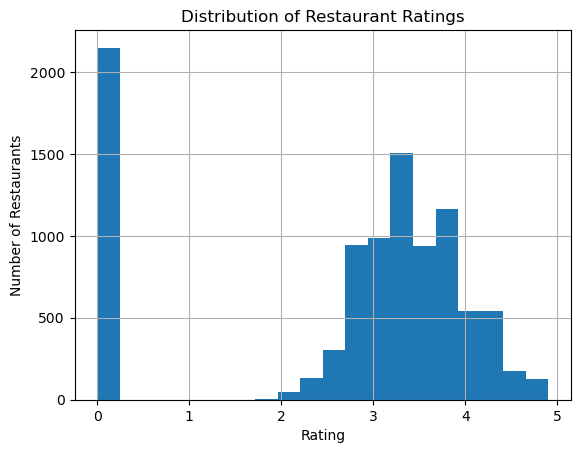

In [3]:
df['Aggregate rating'].hist(bins=20)

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")

plt.show()


In [4]:
df = df[df['Aggregate rating'] > 0]
most_common_rating = df['Aggregate rating'].mode()

print(most_common_rating)

0    3.2
Name: Aggregate rating, dtype: float64


Calculate the average number of votes received by restaurants.

In [20]:
print("The average number of votes received by restaurants:",df['Votes'].mean())
print("The average number of votes indicates moderate customer engagement across restaurants.")

The average number of votes received by restaurants: 202.06248309440087
The average number of votes indicates moderate customer engagement across restaurants.


## Task 2: Cuisine Combination
---
Identify the most common combinations of cuisines in the dataset.

In [6]:
df = df.dropna(subset=['Cuisines'])

In [7]:
cuisine_combo = df['Cuisines'].value_counts()

print(cuisine_combo.head(10))

Cuisines
North Indian                      492
North Indian, Chinese             397
North Indian, Mughlai             294
Cafe                              252
Fast Food                         228
Chinese                           224
North Indian, Mughlai, Chinese    164
Bakery                            130
Bakery, Desserts                  116
Pizza, Fast Food                  113
Name: count, dtype: int64


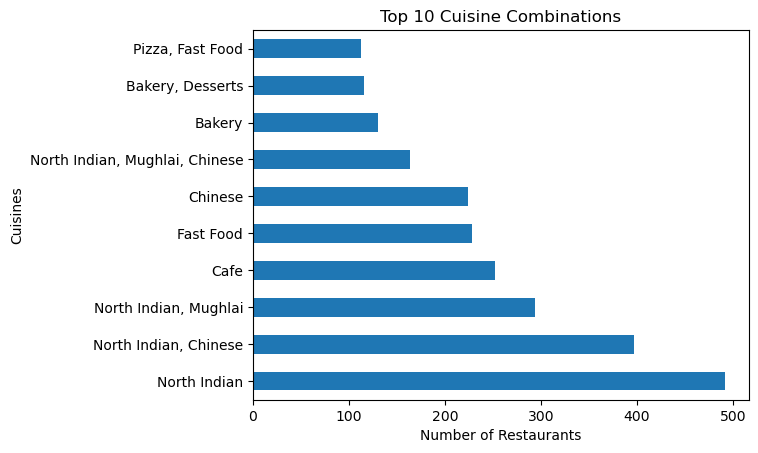

In [8]:
cuisine_combo.head(10).plot(kind='barh')

plt.title("Top 10 Cuisine Combinations")
plt.xlabel("Number of Restaurants")

plt.show()

Determine if certain cuisine combinations tend to have higher ratings.

In [9]:
cuisine_stats = df.groupby('Cuisines').agg({
    'Aggregate rating': 'mean',
    'Restaurant Name': 'count'
})

cuisine_stats.columns = ['Avg Rating', 'Count']

filtered = cuisine_stats[cuisine_stats['Count'] >= 20]

top_rated = filtered.sort_values(by='Avg Rating', ascending=False)

print(top_rated.head(10))



                           Avg Rating  Count
Cuisines                                    
Italian                      3.950000     50
American                     3.920690     29
Mexican                      3.850000     34
Italian, Pizza               3.795652     23
Continental                  3.745000     20
Desserts                     3.597500     40
Desserts, Ice Cream          3.570833     24
Chinese, Thai                3.516667     48
North Indian, Continental    3.515385     26
Burger, Fast Food            3.494872     39


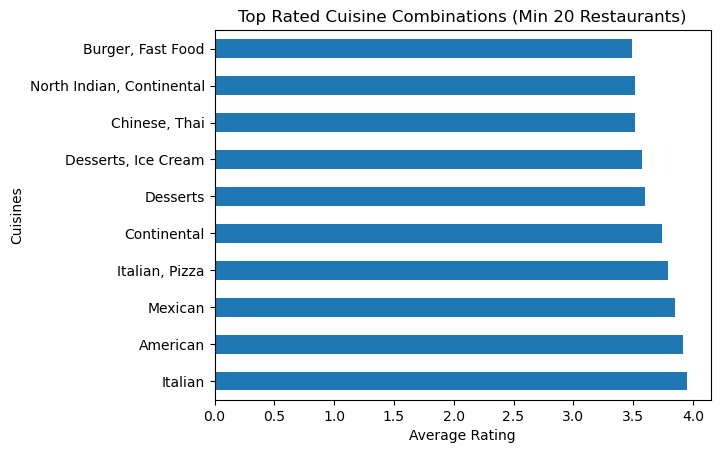

In [10]:
top_rated.head(10)['Avg Rating'].plot(kind='barh')

plt.title("Top Rated Cuisine Combinations (Min 20 Restaurants)")
plt.xlabel("Average Rating")

plt.show()

## Task 3: Geographic Analysis
---
Plot the locations of restaurants on a map using longitude and latitude coordinates.


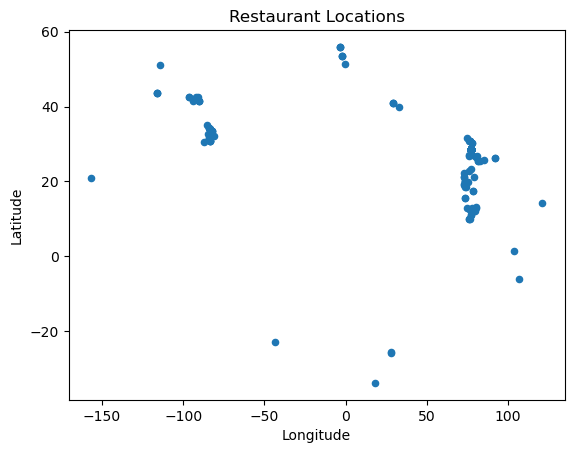

In [18]:
df_geo = df[(df['Latitude'] != 0) & (df['Longitude'] != 0)]
df_geo.sample(500).plot.scatter(x='Longitude', y='Latitude')
plt.title("Restaurant Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

#### Identify any patterns or clusters of restaurants in specific areas.
---

The geographic analysis reveals that restaurants are highly concentrated in urban and commercial areas, forming noticeable clusters. These clusters indicate regions of high demand and accessibility, such as city centers and marketplaces. In contrast, fewer restaurants are found in peripheral areas, suggesting lower demand or population density. The clustering pattern also highlights competitive zones where multiple restaurants operate in close proximity, offering customers a variety of choices.

## Task 4: Restaurant Chains
---
Identify if there are any restaurant chains present in the dataset.


In [12]:
chain_counts = df['Restaurant Name'].value_counts()

chains = chain_counts[chain_counts > 1]

print(chains.head(10))

Restaurant Name
Domino's Pizza      74
Cafe Coffee Day     67
Subway              61
McDonald's          47
Green Chick Chop    44
Pizza Hut           29
Keventers           29
Barbeque Nation     26
Giani               24
Barista             21
Name: count, dtype: int64


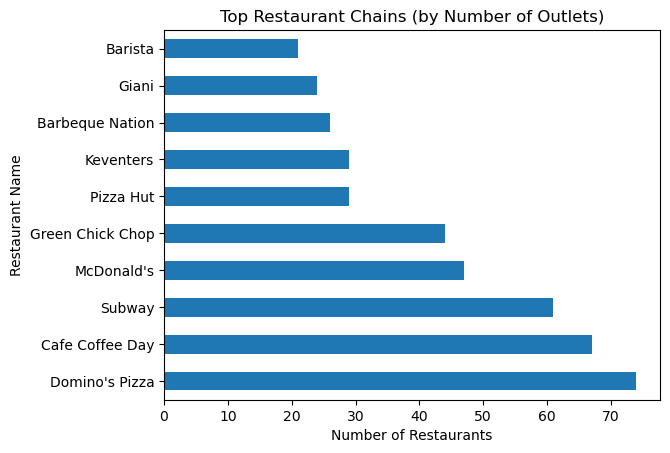

In [14]:
top_chains = chains.sort_values(ascending=False)

top_chains.head(10).plot(kind='barh')

plt.title("Top Restaurant Chains (by Number of Outlets)")
plt.xlabel("Number of Restaurants")

plt.show()

In [19]:
chain_stats = df.groupby('Restaurant Name').agg({
    'Aggregate rating': 'mean',
    'Restaurant Name': 'count'
})

chain_stats.columns = ['Avg Rating', 'Count']

# Filter meaningful chains
filtered_chains = chain_stats[chain_stats['Count'] >= 5]

top_rated_chains = filtered_chains.sort_values(by='Avg Rating', ascending=False)

print(top_rated_chains.head(10))
print(filtered_chains.sort_values(by=['Count','Avg Rating'], ascending=False).head(10))

                 Avg Rating  Count
Restaurant Name                   
Chili's            4.580000      5
Farzi Cafe         4.366667      6
Barbeque Nation    4.353846     26
Punjab Grill       4.340000      5
Mocha              4.185714      7
Happy Hakka        3.860000      5
Texas Roadhouse    3.860000      5
TGI Friday's       3.850000      6
L'Opera            3.820000      5
Starbucks          3.805556     18
                  Avg Rating  Count
Restaurant Name                    
Domino's Pizza      2.925676     74
Cafe Coffee Day     2.997015     67
Subway              3.003279     61
McDonald's          3.410638     47
Green Chick Chop    3.097727     44
Pizza Hut           3.434483     29
Keventers           3.365517     29
Barbeque Nation     4.353846     26
Giani               3.250000     24
Barista             3.219048     21


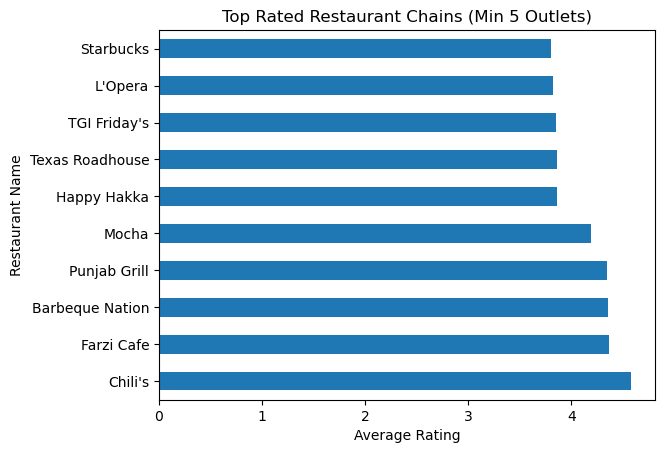

In [16]:
top_rated_chains.head(10)['Avg Rating'].plot(kind='barh')

plt.title("Top Rated Restaurant Chains (Min 5 Outlets)")
plt.xlabel("Average Rating")

plt.show()

### Analyze the ratings and popularity of different restaurant chains.
---
The analysis of restaurant chains shows that some chains have a high number of outlets, indicating strong brand popularity and customer demand. However, not all popular chains maintain high ratings, suggesting that consistency in quality can be challenging at scale. On the other hand, certain chains achieve both high ratings and a reasonable number of outlets, reflecting strong management and customer satisfaction. Overall, successful restaurant chains are those that balance expansion with consistent service quality.
A comparison between popularity and ratings reveals that scalability and quality management are key factors influencing a chain’s success.